Selection_regret_ftse

In [2]:

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

from purgedcv import PurgedGroupKFold, WalkForwardSplit

_project_root = Path.cwd().parent
sys.path.insert(0, str(_project_root))
sys.path.insert(0, str(_project_root / "src"))






In [3]:
tickers = [
    "AZN.L", "HSBA.L", "SHEL.L", "ULVR.L", "BP.L", "GSK.L", "DGE.L",
    "RIO.L", "BATS.L", "REL.L", "LSEG.L", "NG.L", "GLEN.L", "AAL.L",
    "BARC.L", "LLOY.L", "VOD.L", "PRU.L", "CPG.L", "TSCO.L", "IMB.L",
    "NWG.L", "STAN.L", "AV.L", "SSE.L", "RKT.L", "BT-A.L", "SGE.L",
    "SMIN.L", "WTB.L"
]

start_date = "2018-01-01"
end_date = "2024-12-31"

print(f"Downloading data for {len(tickers)} FTSE stocks from {start_date} to {end_date}...")
data_dict = {}
for ticker in tickers:
    try:
        df = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if len(df) > 0:
            data_dict[ticker] = df
            print(f"  {ticker}: {len(df)} rows")
    except Exception as e:
        print(f"  {ticker}: FAILED ({e})")


def norm_yf_col(col):
    """yfinance sometimes returns MultiIndex columns; flatten to plain names."""
    if isinstance(col, tuple):
        parts = [str(p).strip() for p in col if str(p).strip() != ""]
        for p in reversed(parts):
            if p in {"Date", "Open", "High", "Low", "Close", "Volume", "ticker"}:
                return p
        return parts[-1] if parts else ""
    return str(col)


frames = []
for ticker, df_ in data_dict.items():
    tmp = df_.copy().reset_index()
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = pd.Index([norm_yf_col(c) for c in tmp.columns])
    if "Date" not in tmp.columns and "index" in tmp.columns:
        tmp = tmp.rename(columns={"index": "Date"})
    tmp["ticker"] = ticker
    keep = [c for c in ["Date", "Open", "High", "Low", "Close", "Volume", "ticker"] if c in tmp.columns]
    frames.append(tmp[keep])

data = pd.concat(frames, ignore_index=True)
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["Date", "ticker"]).reset_index(drop=True)

print(f"\nCombined dataset: {len(data)} rows, {data['ticker'].nunique()} tickers")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")

  AZN.L: 1767 rows
  HSBA.L: 1767 rows
  SHEL.L: 1767 rows
  ULVR.L: 1767 rows
  BP.L: 1767 rows
  GSK.L: 1767 rows
  DGE.L: 1766 rows
  RIO.L: 1767 rows
  BATS.L: 1767 rows
  REL.L: 1767 rows
  LSEG.L: 1767 rows
  NG.L: 1767 rows
  GLEN.L: 1766 rows
  AAL.L: 1767 rows
  BARC.L: 1767 rows
  LLOY.L: 1767 rows
  VOD.L: 1767 rows
  PRU.L: 1767 rows
  CPG.L: 1767 rows
  TSCO.L: 1767 rows
  IMB.L: 1766 rows
  NWG.L: 1767 rows
  STAN.L: 1767 rows
  AV.L: 1767 rows
  SSE.L: 1767 rows
  RKT.L: 1767 rows
  BT-A.L: 1767 rows
  SGE.L: 1767 rows
  SMIN.L: 1767 rows
  WTB.L: 1767 rows

Combined dataset: 53007 rows, 30 tickers
Date range: 2018-01-02 to 2024-12-30


In [4]:
# Compute evaluation_times and forward_return using per-ticker row shifts,
# not calendar arithmetic. This respects the REAL trading calendar
# (including holidays) automatically, since we never guess what "5 days
# later" means in calendar terms -- we just take the 5th actual traded
# row for that ticker.
data = data.sort_values(['ticker', 'Date']).reset_index(drop=True)

data['returns'] = data.groupby('ticker')['Close'].pct_change()

data['evaluation_times'] = data.groupby('ticker')['Date'].shift(-5)
future_close = data.groupby('ticker')['Close'].shift(-5)
data['forward_return'] = future_close / data['Close'] - 1

data['returns_5d'] = data.groupby('ticker')['returns'].rolling(5).mean().reset_index(0, drop=True)
data['returns_20d'] = data.groupby('ticker')['returns'].rolling(20).mean().reset_index(0, drop=True)
data['volatility_20d'] = data.groupby('ticker')['returns'].rolling(20).std().reset_index(0, drop=True)

before = len(data)
data = data.dropna(
    subset=['evaluation_times', 'forward_return', 'returns_5d', 'returns_20d', 'volatility_20d']
).reset_index(drop=True)
print(f"Dropped {before - len(data)} rows (incomplete features or no future window)")
print(f"Remaining rows: {len(data)}")
print("\nTarget (forward_return) statistics:")
print(data['forward_return'].describe())

Dropped 750 rows (incomplete features or no future window)
Remaining rows: 52257

Target (forward_return) statistics:
count    52257.000000
mean         0.000976
std          0.040349
min         -0.340053
25%         -0.019072
50%          0.001568
75%          0.021845
max          0.542993
Name: forward_return, dtype: float64


In [9]:
# Choose holdout start date (last ~12 months
data = data.sort_values(['Date', 'ticker']).reset_index(drop=True)

holdout_start_date = pd.Timestamp('2024-01-01')

# Split
model_selection_data = data[data['Date'] < holdout_start_date].copy()
holdout_data = data[data['Date'] >= holdout_start_date].copy()

print(f"Model selection data: {len(model_selection_data)} rows, {model_selection_data['Date'].min().date()} to {model_selection_data['Date'].max().date()}")
print(f"Holdout data: {len(holdout_data)} rows, {holdout_data['Date'].min().date()} to {holdout_data['Date'].max().date()}")

# Remove training labels that cross the holdout boundary
# (If a row's evaluation_times is in the holdout period, drop it from model_selection)
model_selection_data = model_selection_data[
    model_selection_data['evaluation_times'] < holdout_start_date
].reset_index(drop=True)

print(f"After removing labels crossing holdout boundary: {len(model_selection_data)} rows")

# Prepare X, y for CV
X = model_selection_data[['returns_5d', 'returns_20d', 'volatility_20d']]
y = (model_selection_data['forward_return'] > 0).astype(int)  # Binary: positive return = 1, else 0
dates = model_selection_data['Date'].values
tickers = model_selection_data['ticker'].values

print(f"\nTarget distribution (% positive returns): {y.mean():.2%}")
print(f"Feature matrix shape: {X.shape}")
print(f"Dates shape: {dates.shape}, Tickers shape: {tickers.shape}")

# Same for holdout
X_holdout = holdout_data[['returns_5d', 'returns_20d', 'volatility_20d']]
y_holdout = (holdout_data['forward_return'] > 0).astype(int)

print(f"\nHoldout target distribution: {y_holdout.mean():.2%}")

Model selection data: 44820 rows, 2018-01-30 to 2023-12-29
Holdout data: 7437 rows, 2024-01-02 to 2024-12-19
After removing labels crossing holdout boundary: 44670 rows

Target distribution (% positive returns): 51.91%
Feature matrix shape: (44670, 3)
Dates shape: (44670,), Tickers shape: (44670,)

Holdout target distribution: 52.53%


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("BASELINE COMPARISON: Testing for look-ahead leakage")
print("=" * 80)

def make_pipeline():
    """A fresh, unfitted pipeline -- created new for every fold so nothing
    (not even feature scaling) is ever fit on data outside that fold's
    training rows."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000)),
    ])

prediction_times = pd.Series(model_selection_data['Date'].values, index=range(len(model_selection_data)))
evaluation_times = pd.Series(model_selection_data['evaluation_times'].values, index=range(len(model_selection_data)))
groups = pd.Series(model_selection_data['Date'].values, index=range(len(model_selection_data)))

X_reset = X.reset_index(drop=True)
y_reset = y.reset_index(drop=True)

cv_results = []

def run_cv(name, splitter, split_kwargs=None):
    split_kwargs = split_kwargs or {}
    aucs = []
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X_reset, **split_kwargs)):
        pipe = make_pipeline()
        pipe.fit(X_reset.iloc[train_idx], y_reset.iloc[train_idx])
        preds = pipe.predict_proba(X_reset.iloc[test_idx])[:, 1]
        auc = roc_auc_score(y_reset.iloc[test_idx], preds)
        aucs.append(auc)
        print(f"  Fold {fold}: AUC = {auc:.4f} (train={len(train_idx)}, test={len(test_idx)})")
    cv_results.append({'method': name, 'mean_auc': np.mean(aucs), 'std_auc': np.std(aucs)})

print("1. KFold(shuffle=False)")
run_cv('KFold(shuffle=False)', KFold(n_splits=5, shuffle=False))

print("\n2. KFold(shuffle=True)")
run_cv('KFold(shuffle=True)', KFold(n_splits=5, shuffle=True, random_state=42))
print("3. PurgedGroupKFold")
cv_purged = PurgedGroupKFold(
    n_splits=5,
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
    groups=groups,
)
run_cv('PurgedGroupKFold', cv_purged)

print("\n4. WalkForwardSplit")


initial_train_end = pd.Timestamp('2019-01-01')
n_reserved = int((model_selection_data['Date'] < initial_train_end).sum())
n_remaining = len(X_reset) - n_reserved
test_size = n_remaining // 5

print(f"Reserving {n_reserved} rows as initial training-only period (before {initial_train_end.date()})")
print(f"Remaining {n_remaining} rows split into 5 walk-forward test folds of size {test_size}")

cv_wf = WalkForwardSplit(
    n_splits=5,
    test_size=test_size,
    window="expanding",
    prediction_times=prediction_times,
    evaluation_times=evaluation_times,
)
run_cv('WalkForwardSplit', cv_wf)


BASELINE COMPARISON: Testing for look-ahead leakage
1. KFold(shuffle=False)
  Fold 0: AUC = 0.5117 (train=35736, test=8934)
  Fold 1: AUC = 0.5158 (train=35736, test=8934)
  Fold 2: AUC = 0.5128 (train=35736, test=8934)
  Fold 3: AUC = 0.5232 (train=35736, test=8934)
  Fold 4: AUC = 0.5159 (train=35736, test=8934)

2. KFold(shuffle=True)
  Fold 0: AUC = 0.5159 (train=35736, test=8934)
  Fold 1: AUC = 0.5106 (train=35736, test=8934)
  Fold 2: AUC = 0.5185 (train=35736, test=8934)
  Fold 3: AUC = 0.5222 (train=35736, test=8934)
  Fold 4: AUC = 0.5136 (train=35736, test=8934)
3. PurgedGroupKFold
  Fold 0: AUC = 0.5117 (train=35610, test=8940)
  Fold 1: AUC = 0.5154 (train=35490, test=8940)
  Fold 2: AUC = 0.5178 (train=35490, test=8940)
  Fold 3: AUC = 0.5234 (train=35490, test=8940)
  Fold 4: AUC = 0.5151 (train=35640, test=8910)

4. WalkForwardSplit
Reserving 6990 rows as initial training-only period (before 2019-01-01)
Remaining 37680 rows split into 5 walk-forward test folds of size 7

In [ ]:
print("\n5. Same date-blocks as PurgedGroupKFold, but WITHOUT purge/embargo")
# Reuse PurgedGroupKFold's exact fold boundaries, but skip the purge/embargo
# step -- this isolates what purging changes, since everything else
# (which dates go in which fold) is held identical to method 3 above.
aucs_unpurged_sameblocks = []
for fold, (_train_idx, test_idx) in enumerate(cv_purged.split(X_reset)):
    # cv_purged.split already returns PURGED train_idx -- to get the
    # "same blocks, no purge" comparison, we instead take all rows NOT
    # in this fold's test block as train, ignoring the purge/embargo trim.
    test_dates = set(model_selection_data['Date'].iloc[test_idx])
    naive_test_mask = model_selection_data['Date'].isin(test_dates)
    naive_test_idx = np.where(naive_test_mask.values)[0]
    naive_train_idx = np.where(~naive_test_mask.values)[0]

    pipe = make_pipeline()
    pipe.fit(X_reset.iloc[naive_train_idx], y_reset.iloc[naive_train_idx])
    preds = pipe.predict_proba(X_reset.iloc[naive_test_idx])[:, 1]
    auc = roc_auc_score(y_reset.iloc[naive_test_idx], preds)
    aucs_unpurged_sameblocks.append(auc)
    print(f"  Fold {fold}: AUC = {auc:.4f} (train={len(naive_train_idx)}, test={len(naive_test_idx)})")

cv_results.append({
    'method': 'Same blocks as PurgedGroupKFold, no purge',
    'mean_auc': np.mean(aucs_unpurged_sameblocks),
    'std_auc': np.std(aucs_unpurged_sameblocks),
})


results_df = pd.DataFrame(cv_results)

print("Results summary:")
print(results_df.to_string(index=False))

print("\nDescriptive statistics:")
print(results_df[['mean_auc', 'std_auc']].describe())


5. Same date-blocks as PurgedGroupKFold, but WITHOUT purge/embargo
  Fold 0: AUC = 0.5117 (train=35730, test=8940)
  Fold 1: AUC = 0.5155 (train=35730, test=8940)
  Fold 2: AUC = 0.5126 (train=35730, test=8940)
  Fold 3: AUC = 0.5233 (train=35730, test=8940)
  Fold 4: AUC = 0.5159 (train=35760, test=8910)
Results summary:
                                   method  mean_auc  std_auc
                     KFold(shuffle=False)  0.515874 0.004006
                      KFold(shuffle=True)  0.516158 0.003990
                         PurgedGroupKFold  0.516683 0.003886
                         WalkForwardSplit  0.517225 0.012936
Same blocks as PurgedGroupKFold, no purge  0.515776 0.004085

Descriptive statistics:
       mean_auc   std_auc
count  5.000000  5.000000
mean   0.516343  0.005781
std    0.000606  0.004000
min    0.515776  0.003886
25%    0.515874  0.003990
50%    0.516158  0.004006
75%    0.516683  0.004085
max    0.517225  0.012936


In [18]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

candidate_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, C=1.0),
    'RandomForest_shallow': RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42),
    'RandomForest_deep': RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42),
}

def make_pipeline_for(model):
    return Pipeline([('scaler', StandardScaler()), ('clf', model)])

def cv_score_candidate(splitter, model, x_data, y_data):
    """Mean AUC of one candidate model under one CV splitter's folds."""
    aucs = []
    for _train_idx, test_idx in splitter.split(x_data):
        pipe = make_pipeline_for(clone(model))
        pipe.fit(x_data.iloc[_train_idx], y_data.iloc[_train_idx])
        preds = pipe.predict_proba(x_data.iloc[test_idx])[:, 1]
        aucs.append(roc_auc_score(y_data.iloc[test_idx], preds))
    return np.mean(aucs)

method_splitters = {
    'KFold(shuffle=False)': KFold(n_splits=5, shuffle=False),
    'KFold(shuffle=True)': KFold(n_splits=5, shuffle=True, random_state=42),
    'PurgedGroupKFold': PurgedGroupKFold(
        n_splits=5, prediction_times=prediction_times,
        evaluation_times=evaluation_times, groups=groups,
    ),
    'WalkForwardSplit': WalkForwardSplit(
        n_splits=5, test_size=test_size, window="expanding",
        prediction_times=prediction_times, evaluation_times=evaluation_times,
    ),
}

selection_results = []
for method_name, splitter in method_splitters.items():
    print(f"\n{method_name}:")
    candidate_scores = {}
    for cand_name, model in candidate_models.items():
        score = cv_score_candidate(splitter, model, X_reset, y_reset)
        candidate_scores[cand_name] = score
        print(f"  {cand_name}: CV AUC = {score:.4f}")

    winner_name = max(candidate_scores, key=candidate_scores.get)
    print(f"  --> Winner: {winner_name} (CV AUC = {candidate_scores[winner_name]:.4f})")

    winner_pipe = make_pipeline_for(clone(candidate_models[winner_name]))
    winner_pipe.fit(X_reset, y_reset)
    holdout_preds = winner_pipe.predict_proba(X_holdout)[:, 1]
    holdout_auc = roc_auc_score(y_holdout, holdout_preds)
    print(f"  Deployment (holdout) AUC: {holdout_auc:.4f}")

    selection_results.append({
        'cv_method': method_name,
        'picked_model': winner_name,
        'cv_auc_estimate': candidate_scores[winner_name],
        'holdout_auc': holdout_auc,
    })

selection_df = pd.DataFrame(selection_results)
print("\n" + "=" * 70)
print("SELECTION REGRET SUMMARY")
print("=" * 70)
print(selection_df.to_string(index=False))


KFold(shuffle=False):
  LogisticRegression: CV AUC = 0.5159
  RandomForest_shallow: CV AUC = 0.5125
  RandomForest_deep: CV AUC = 0.5079
  --> Winner: LogisticRegression (CV AUC = 0.5159)
  Deployment (holdout) AUC: 0.5189

KFold(shuffle=True):
  LogisticRegression: CV AUC = 0.5162
  RandomForest_shallow: CV AUC = 0.5251
  RandomForest_deep: CV AUC = 0.5512
  --> Winner: RandomForest_deep (CV AUC = 0.5512)
  Deployment (holdout) AUC: 0.4963

PurgedGroupKFold:
  LogisticRegression: CV AUC = 0.5167
  RandomForest_shallow: CV AUC = 0.5137
  RandomForest_deep: CV AUC = 0.5067
  --> Winner: LogisticRegression (CV AUC = 0.5167)
  Deployment (holdout) AUC: 0.5189

WalkForwardSplit:
  LogisticRegression: CV AUC = 0.5172
  RandomForest_shallow: CV AUC = 0.5065
  RandomForest_deep: CV AUC = 0.5030
  --> Winner: LogisticRegression (CV AUC = 0.5172)
  Deployment (holdout) AUC: 0.5189

SELECTION REGRET SUMMARY
           cv_method       picked_model  cv_auc_estimate  holdout_auc
KFold(shuffle=Fals

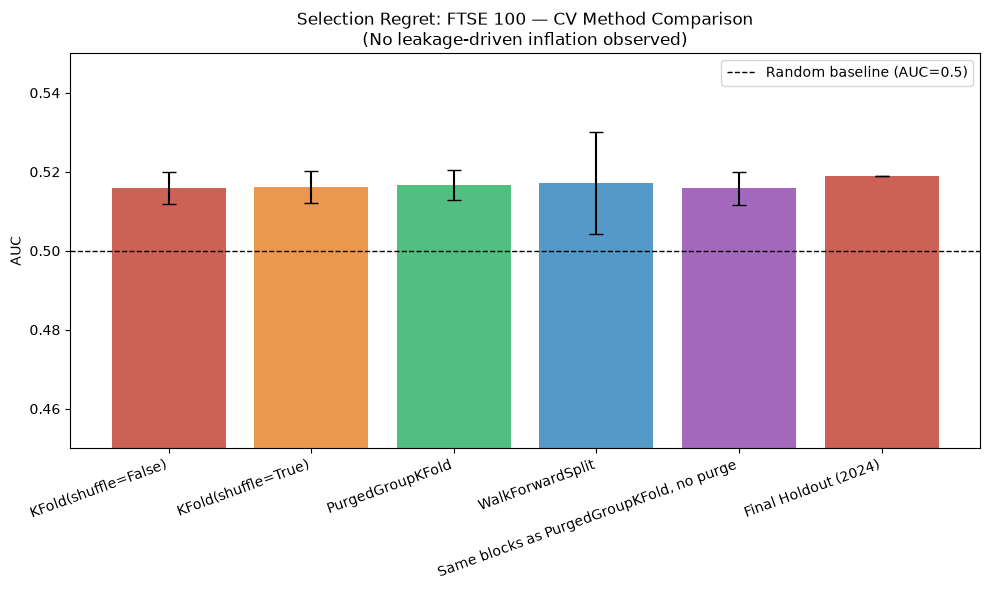


Plot saved as ftse_selection_regret.png


In [17]:
# Step 9: Visualize the results

fig, ax = plt.subplots(figsize=(10, 6))

methods = [*results_df['method'].tolist(), 'Final Holdout (2024)']
means = [*results_df['mean_auc'].tolist(), holdout_auc]
stds = [*results_df['std_auc'].tolist(), 0]

colors = ['#c0392b', '#e67e22', '#27ae60', '#2980b9', '#8e44ad']

bars = ax.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Random baseline (AUC=0.5)')
ax.set_ylabel('AUC')
ax.set_title('Selection Regret: FTSE 100 — CV Method Comparison\n(No leakage-driven inflation observed)')
ax.set_ylim(0.45, 0.55)
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('ftse_selection_regret.png', dpi=150)
plt.show()

print("\nPlot saved as ftse_selection_regret.png")